# NC County Health Burden and Access Analysis

This notebook explores health outcomes and healthcare access indicators in counties of North Carolina using public health data. The goal is to identify patterns in health burdens and access to care while practicing a reproducible data analysis workflow in Python.

## Setup

I start by importing the Python tools needed for loading, inspecting, and cleaning the dataset.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Source

The raw data comes from County Health Rankings & Roadmaps, produced by the University of Wisconsin Population Health Institute. The original Excel workbook contains several sheets, so the first task is to identify a sheet which contains the health data needed for analysis.

In [2]:
data_path = Path("../data/2025 County Health Rankings Data - v4.xlsx")
excel_file = pd.ExcelFile(data_path)
excel_file.sheet_names

['Introduction',
 'Select Measure Data',
 'Select Measure Sources & Years',
 'Additional Measure Data',
 'Addtl Measure Sources & Years',
 'Health Groups']

## Load Selected Measure Data

Based on an initial inspection of the workbook, the `Select Measure Data` sheet contains the information we need. I load that sheet directly and inspect its structure before cleaning.

In [3]:
raw = pd.read_excel(data_path, sheet_name="Select Measure Data", header=1)
raw.head()

,FIPS,State,County,Unreliable,Deaths,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,National Z-Score,YPLL Rate (Hispanic (all races)),...,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - Low,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - High,Injury Death Rate (Non-Hispanic White),Injury Death Rate (Non-Hispanic White) 95% CI - Low,Injury Death Rate (Non-Hispanic White) 95% CI - High,# Associations,Social Association Rate,National Z-Score.27,% Household Income Required for Child Care Expenses,National Z-Score.28
0,1000,Alabama,NaN,NaN,102760.0,11853.247248,11744.014820,11962.479676,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5916.0,11.658760,NaN,25.547114,NaN
1,1001,Alabama,Autauga,NaN,1008.0,9938.263382,9021.297133,10855.229632,-0.144182,NaN,...,NaN,NaN,66.353516,55.322574,77.384459,67.0,11.211700,0.043429,21.835108,-0.961825
2,1003,Alabama,Baldwin,NaN,3944.0,8957.112686,8499.339223,9414.886148,-0.400274,4636.48424,...,NaN,NaN,86.954622,81.060141,92.849104,239.0,9.698298,0.308739,19.354057,-1.316051
3,1005,Alabama,Barbour,NaN,587.0,12738.656137,11133.499025,14343.813250,0.586752,NaN,...,NaN,NaN,92.500356,69.083690,121.301910,22.0,8.904720,0.447859,28.579628,0.001105
4,1007,Alabama,Bibb,NaN,509.0,11708.948038,10166.716823,13251.179253,0.317987,NaN,...,NaN,NaN,110.157489,88.691939,135.248986,19.0,8.634401,0.495248,26.582776,-0.283990


In [4]:
raw.shape

(3210, 225)

## Filter to North Carolina Counties

The workbook contains data for counties in all US states. For this project, I restrict the analysis to North Carolina counties.

In [5]:
nc = raw[raw["State"] == "North Carolina"].copy()

nc.shape

(101, 225)

In [6]:
nc.head()

,FIPS,State,County,Unreliable,Deaths,Years of Potential Life Lost Rate,95% CI - Low,95% CI - High,National Z-Score,YPLL Rate (Hispanic (all races)),...,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - Low,Injury Death Rate (Non-Hispanic 2+ races) 95% CI - High,Injury Death Rate (Non-Hispanic White),Injury Death Rate (Non-Hispanic White) 95% CI - Low,Injury Death Rate (Non-Hispanic White) 95% CI - High,# Associations,Social Association Rate,National Z-Score.27,% Household Income Required for Child Care Expenses,National Z-Score.28
1938,37000,North Carolina,NaN,NaN,168309.0,9440.558782,9372.868286,9508.249279,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12040.0,11.253417,NaN,25.139938,NaN
1939,37001,North Carolina,Alamance,NaN,2843.0,9570.576671,9028.104576,10113.048766,-0.240152,5126.300063,...,NaN,NaN,116.459188,107.277224,125.641153,173.0,9.809870,0.289180,21.976052,-0.941702
1940,37003,North Carolina,Alexander,NaN,754.0,10846.763323,9578.231275,12115.295370,0.092947,NaN,...,NaN,NaN,NaN,NaN,NaN,55.0,15.063541,-0.631826,22.586382,-0.854564
1941,37005,North Carolina,Alleghany,NaN,227.0,8598.052565,6418.697024,10777.408107,-0.493992,NaN,...,NaN,NaN,NaN,NaN,NaN,14.0,12.516764,-0.185358,26.660368,-0.272912
1942,37007,North Carolina,Anson,NaN,609.0,15560.325955,13639.347836,17481.304074,1.323240,NaN,...,NaN,NaN,151.515152,119.955972,188.833086,29.0,13.061886,-0.280922,28.887393,0.045045


In [7]:
nc = nc[nc["County"].notna()].copy()

nc.shape

(100, 225)

In [8]:
nc.columns.tolist()

['FIPS',
 'State',
 'County',
 'Unreliable',
 'Deaths',
 'Years of Potential Life Lost Rate',
 '95% CI - Low',
 '95% CI - High',
 'National Z-Score',
 'YPLL Rate (Hispanic (all races))',
 'YPLL Rate (Hispanic (all races)) 95% CI - Low',
 'YPLL Rate (Hispanic (all races)) 95% CI - High',
 'YPLL Rate (Hispanic (all races)) Unreliable',
 'YPLL Rate (Non-Hispanic AIAN)',
 'YPLL Rate (Non-Hispanic AIAN) 95% CI - Low',
 'YPLL Rate (Non-Hispanic AIAN) 95% CI - High',
 'YPLL Rate (Non-Hispanic AIAN) Unreliable',
 'YPLL Rate (Non-Hispanic Asian)',
 'YPLL Rate (Non-Hispanic Asian) 95% CI - Low',
 'YPLL Rate (Non-Hispanic Asian) 95% CI - High',
 'YPLL Rate (Non-Hispanic Asian) Unreliable',
 'YPLL Rate (Non-Hispanic Black)',
 'YPLL Rate (Non-Hispanic Black) 95% CI - Low',
 'YPLL Rate (Non-Hispanic Black) 95% CI - High',
 'YPLL Rate (Non-Hispanic Black) Unreliable',
 'YPLL Rate (Non-Hispanic Native Hawaiian and Other Pacific Islander)',
 'YPLL Rate (Non-Hispanic Native Hawaiian and Other Pacific Is

## Select Variables for Analysis

The original dataset contains more than 200 variables. I select a smaller group of these for an initial analysis.

In [9]:
analysis_cols = [
    "FIPS",
    "County",
    "Years of Potential Life Lost Rate",
    "% Fair or Poor Health",
    "Injury Death Rate",
    "Primary Care Physicians Ratio",
    "% Uninsured",
    "% Children in Poverty",
    "% Unemployed",
    "% Households with Broadband Access"
]

nc_analysis = nc[analysis_cols].copy()

nc_analysis.head()

,FIPS,County,Years of Potential Life Lost Rate,% Fair or Poor Health,Injury Death Rate,Primary Care Physicians Ratio,% Uninsured,% Children in Poverty,% Unemployed,% Households with Broadband Access
1939,37001,Alamance,9570.576671,19.7,98.306630,2595:1,12.580197,16.0,3.394925,88.186906
1940,37003,Alexander,10846.763323,17.3,91.670396,5235:1,11.926507,17.4,3.219897,84.634761
1941,37005,Alleghany,8598.052565,21.1,120.231131,1004:1,17.302539,24.5,4.477262,81.045752
1942,37007,Anson,15560.325955,23.4,130.861134,2206:1,12.467217,33.0,4.033908,84.387780
1943,37009,Ashe,9771.245666,17.8,98.300800,2055:1,13.603904,22.0,3.003120,80.181682


## Check for Missing Values

Before beginning analysis, I check whether any of the selected variables contain missing values. Identifying missing data is important because it can affect visualizations, summary statistics, and comparisons across counties.

In [10]:
nc_analysis.isna().sum()

FIPS                                  0
County                                0
Years of Potential Life Lost Rate     0
% Fair or Poor Health                 0
Injury Death Rate                     0
Primary Care Physicians Ratio         2
% Uninsured                           0
% Children in Poverty                 0
% Unemployed                          0
% Households with Broadband Access    0
dtype: int64

The selected variables contain very little missing data overall. Above, we find that there are two counties missing values for `Primary Care Physicians Ratio`. Next I identify exactly which counties.

In [11]:
nc_analysis[nc_analysis["Primary Care Physicians Ratio"].isna()]

,FIPS,County,Years of Potential Life Lost Rate,% Fair or Poor Health,Injury Death Rate,Primary Care Physicians Ratio,% Uninsured,% Children in Poverty,% Unemployed,% Households with Broadband Access
1975,37073,Gates,11365.864398,18.9,108.405001,NaN,9.177892,19.5,3.344224,74.283005
2027,37177,Tyrrell,9472.843693,20.1,124.056095,NaN,15.693582,29.9,5.056604,74.474053


As we can see, Gates County and Tyrrell County are the two counties missing the data.

This may reflect unavailable or suppressed provider reporting data. Because the missing data is limited to just two counties and affects only one variable, I retain these counties in the dataset and handle missing values as needed in later analysis steps.

## Prepare Variables for Analysis

Some variables require additional preprocessing before they can be used in numerical analysis or visualization.

The `Primary Care Physicians Ratio` variable is stored as text values such as `2595:1` rather than as numeric data. To make the variable usable for analysis and visualization, I extract the population-to-physician ratio as a numeric variable. First, I double-check that the ratios are always recorded with a ratio of the form "population:1", meaning it is expressed in terms of a number of people per physician (as opposed to, say, a ratio of the form 123 people : 2 physicians), with the only exception of the missing values for Gates County and Tyrrell County, which should correspond to missing values, which read as instances of "NaN".

In [12]:
pcp_parts = nc_analysis["Primary Care Physicians Ratio"].str.split(":", expand=True)

pcp_parts[1].value_counts(dropna=False)

1
1      98
NaN     2
Name: count, dtype: int64

The data passed the check. Now I record the ratios as numerical values.

In [13]:
nc_analysis["PCP_Ratio_Numeric"] = pd.to_numeric(pcp_parts[0], errors="coerce")

## Exploratory Visualization

I begin exploratory analysis by examining the relationship between childhood poverty and premature mortality across North Carolina counties.

<Axes: xlabel='% Children in Poverty', ylabel='Years of Potential Life Lost Rate'>

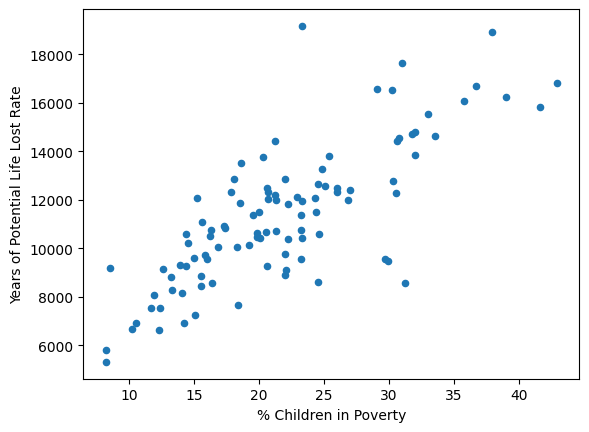

In [14]:
nc_analysis.plot.scatter(
    x="% Children in Poverty",
    y="Years of Potential Life Lost Rate"
)

The scatter plot shows a clear positive association between childhood poverty and years of potential life lost across North Carolina counties. In general, counties with higher percentages of children living in poverty also tend to have higher rates of premature mortality.

There do not appear to be any extreme outliers dominating the relationship. The spread of the data may increase somewhat as childhood poverty increases, suggesting greater variability in years of potential life lost among higher-poverty counties, although this would require further investigation.

Next, let's examine the relationship between childhood poverty and self-reported health outcomes across North Carolina counties.

<Axes: xlabel='% Children in Poverty', ylabel='% Fair or Poor Health'>

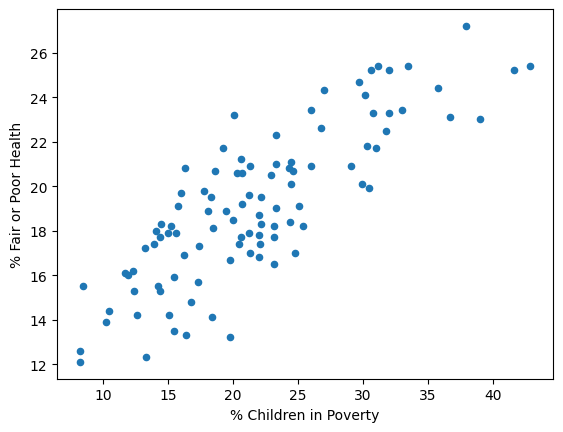

In [15]:
nc_analysis.plot.scatter(
    x="% Children in Poverty",
    y="% Fair or Poor Health"
)

A similar positive relationship appears between childhood poverty and the percentage of adults reporting fair or poor health. Compared with the premature mortality plot, the spread does not appear to vary significantly across the different childhood poverty rates.

Now let's consider the relationship between broadband internet access and childhood poverty.

<Axes: xlabel='% Households with Broadband Access', ylabel='% Children in Poverty'>

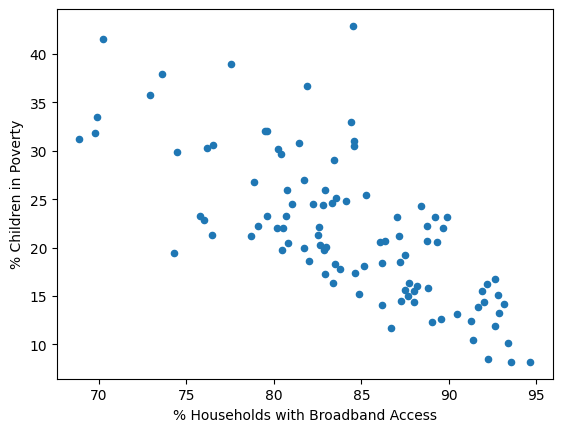

In [16]:
nc_analysis.plot.scatter(
    x="% Households with Broadband Access",
    y="% Children in Poverty"
)

Counties with lower household broadband access tend to have higher childhood poverty rates. This suggests that health burden is connected not only to healthcare access, but also to broader socioeconomic and infrastructure conditions.

## Access Mismatch Exploration

The primary care physician ratio captures one dimension of healthcare access: the number of residents per primary care physician. Lower values indicate relatively better access.

Here I look for counties that appear to have relatively favorable primary care physician access, but still show high health burden. This is an exploratory way to identify counties where healthcare access alone may not explain observed outcomes.

In [17]:
access_df = nc_analysis.dropna(subset=["PCP_Ratio_Numeric"]).copy()

good_access_cutoff = access_df["PCP_Ratio_Numeric"].quantile(0.5)
high_ypll_cutoff = access_df["Years of Potential Life Lost Rate"].quantile(0.75)
high_poor_health_cutoff = access_df["% Fair or Poor Health"].quantile(0.75)

thresholds = pd.DataFrame({
    "Measure": [
        "Residents per primary care physician: 50th percentile",
        "Years of potential life lost rate: 75th percentile",
        "% fair or poor health: 75th percentile"
    ],
    "Threshold": [
        good_access_cutoff,
        high_ypll_cutoff,
        high_poor_health_cutoff
    ]
})

thresholds

,Measure,Threshold
0,Residents per primary care physician: 50th per...,2158.000000
1,Years of potential life lost rate: 75th percen...,12750.160859
2,% fair or poor health: 75th percentile,21.175000


For comparison purposes, I define relatively favorable primary care physician access as being at or below the median number of residents per primary care physician. I define high health burden as being in the highest quartile for either premature mortality or self-reported fair/poor health.

These thresholds are not intended as formal clinical cutoffs. They are only used here to identify counties that stand out for further investigation.

Now let's identify which counties simultaneously have favorable primary care physician access and high health burden.

In [18]:
good_access_cutoff = access_df["PCP_Ratio_Numeric"].quantile(0.50)

mismatch_counties = access_df[
    (access_df["PCP_Ratio_Numeric"] <= good_access_cutoff)
    & (
        (access_df["Years of Potential Life Lost Rate"] >= high_ypll_cutoff)
        | (access_df["% Fair or Poor Health"] >= high_poor_health_cutoff)
    )
].copy()

display_cols = [
    "County",
    "Primary Care Physicians Ratio",
    "PCP_Ratio_Numeric",
    "Years of Potential Life Lost Rate",
    "% Fair or Poor Health",
    "% Children in Poverty",
    "% Uninsured",
    "% Households with Broadband Access"
]

mismatch_counties[display_cols].set_index("County")

,Primary Care Physicians Ratio,PCP_Ratio_Numeric,Years of Potential Life Lost Rate,% Fair or Poor Health,% Children in Poverty,% Uninsured,% Households with Broadband Access
County,,,,,,,
Caldwell,2012:1,2012.0,12862.812420,18.9,18.1,13.088596,85.158396
Cumberland,1416:1,1416.0,12884.378328,18.7,22.0,10.615419,89.691534
Halifax,2099:1,2099.0,15814.706228,25.2,41.6,12.244486,70.225467
Hertford,1637:1,1637.0,13850.631790,25.2,32.0,11.856907,79.517349
Jones,1543:1,1543.0,12786.449306,21.8,30.3,13.603958,76.194125
Lenoir,1765:1,1765.0,14784.922929,23.3,32.0,12.888094,79.590057
Robeson,1972:1,1972.0,18937.527286,27.2,37.9,15.197265,73.617350
Scotland,1711:1,1711.0,16834.590939,25.4,42.9,11.078356,84.534583
Swain,1571:1,1571.0,19176.993616,22.3,23.3,19.418414,75.792359


This mismatch table identifies counties with primary care physician access better than the median cutoff but high health burden on at least one selected outcome measure. These counties provide examples for exploring the possibility that physician availability alone does not fully explain differences in premature mortality or self-reported health.

### Comparing Mismatch Counties with All North Carolina Counties

To add context to the mismatch table, I compare the median values of selected socioeconomic and access variables for the mismatch counties against the median values for all North Carolina counties with primary care physician data.

In [19]:
comparison_vars = [
    "Years of Potential Life Lost Rate",
    "% Fair or Poor Health",
    "% Children in Poverty",
    "% Uninsured",
    "% Households with Broadband Access",
    "PCP_Ratio_Numeric"
]

comparison = pd.DataFrame({
    "All NC counties median": access_df[comparison_vars].median(),
    "Mismatch counties median": mismatch_counties[comparison_vars].median()
})

comparison

,All NC counties median,Mismatch counties median
Years of Potential Life Lost Rate,10883.161581,14784.922929
% Fair or Poor Health,18.800000,23.300000
% Children in Poverty,20.950000,32.000000
% Uninsured,12.267668,12.888094
% Households with Broadband Access,84.461181,79.517349
PCP_Ratio_Numeric,2158.000000,1711.000000


The mismatch counties differ from the statewide median in the expected directions for physician access and health burden, since these variables were used to define the group. They also show higher childhood poverty and lower household broadband access, consistent with the broader patterns observed above.

In [20]:
nc_analysis["% Uninsured"].describe()

count    100.000000
mean      12.464222
std        2.161015
min        8.124213
25%       11.011617
50%       12.267668
75%       13.465909
max       19.418414
Name: % Uninsured, dtype: float64

The uninsured rate for the mismatch counties, however, is close to the statewide median. More concretely, the median uninsured rate in the mismatch group differs from the statewide mean by less than one quarter of a standard deviation (calculated below.) This suggests that uninsured rate does not strongly distinguish the mismatch group in this comparison.

In [21]:
uninsured_mean = nc_analysis["% Uninsured"].mean()
uninsured_std = nc_analysis["% Uninsured"].std()
mismatch_uninsured_median = mismatch_counties["% Uninsured"].median()

uninsured_difference_sd = (
    (mismatch_uninsured_median - uninsured_mean) / uninsured_std
)

uninsured_difference_sd

np.float64(0.19614470895200214)

## Summary

This notebook uses Health Rankings data to explore health burden, healthcare access, and socioeconomic conditions in North Carolina.

The exploratory plots show positive associations between socioeconomic factors such as childhood poverty and lack of broadband access, and both premature mortality and self-reported fair/poor health.

The access mismatch check identifies counties with better than average primary care physician access but high health burden, suggesting that physician availability is not the primary determining factor in health outcomes. In this subgroup, uninsured rate is close to the statewide average, while childhood poverty and broadband access appear more distinct.

Future work could examine additional access measures, regional patterns, or changes over time.

In [22]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

nc_analysis.to_csv("../data/processed/nc_county_health_analysis.csv", index=False)